## Imports das Bibliotecas

In [1]:
## Imports Geral
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Import para Visualização de Dados
from wordcloud import WordCloud

# Extração de Texto
from nltk.corpus import stopwords

# Importações de Metrica
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Preprocessamento
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

# Modelos
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

import warnings

# Suprimir todos os warnings
warnings.filterwarnings("ignore")

# Analise dos dados

In [ ]:
df = pd.read_csv("cor_da_justica.csv")
remover_colunas = ["Unnamed: 0", "uris.uriAutores", "uris.uriPropPrincipal",
                   "uris.uriUltimoRelator", "foto", "cpf",  "uris.uriPartido",]
df = df.drop(columns=remover_colunas)
df = df.dropna(subset=["ementa"])
df = df.drop_duplicates().reset_index(drop=True)
df.info()

In [3]:
df["ementa"] = df.apply(lambda x: x["ementa"] + ' ' +  x["ementaDetalhada"] if x["ementaDetalhada"] == str(x["ementaDetalhada"]) else x["ementa"] , axis=1)
df["ementa"] = df.apply(lambda x: x["ementa"] + ' ' +  x["ementa_principal"] if x["ementa_principal"] != str("vazio") else x["ementa"] , axis=1)
df["ementa"] = df.apply(lambda x: x["ementa"] + ' ' +  x["keywords"] if x["keywords"] == str(x["keywords"]) else x["ementa"] , axis=1)
df["ementa"] = df.apply(lambda x: x["ementa"] + ' ' +  x["keywords_principal"] if x["keywords_principal"] == str(x["keywords_principal"]) else x["ementa"] , axis=1)

In [4]:
df = df.drop(columns=["ementaDetalhada", "ementa_principal", 'keywords', 'keywords_principal'])

In [5]:
df["situacao"].loc[(df["situacao"] == "Aguardando Designação de Relator(a)" ) | (df["situacao"] == "Aguardando Parecer") | (df["situacao"] == "Aguardando Encaminhamento") | (df["situacao"] == "Aguardando Definição Encaminhamento") | (df["situacao"] == "Aguardando Recurso") | (df["situacao"] == "Aguardando Despacho de Arquivamento ") | (df["situacao"] == "Aguardando Deliberação")  | (df["situacao"] == "Aguardando Designação - Aguardando Devolução de Relator(a) que deixou de ser Membro") | (df["situacao"] == "Aguardando Análise de Parecer") | (df["situacao"] == "Arquivada") ] = "AGUARDANDO"
df["situacao"].loc[(df["situacao"] == "Tramitando em Conjunto" ) | (df["situacao"] == "Pronta para Pauta")] = "TRAMITANDO"
df["situacao"] = df["situacao"].fillna("RECUSADO")

In [6]:
df = df.drop(df[(df['cor'] == "#NE") | (
    df["cor"] == "#NE#")].index).reset_index(drop=True)

df["cor"].loc[(df["cor"] == "AMARELA") | (
    df["cor"] == "NÃO DIVULGÁVEL") | (df["cor"] == "INDÍGENA") | (df["cor"] == "PARDA") | (df["cor"] == "PRETA")] = "OUTROS"

In [7]:
cor = df["cor"].value_counts().reset_index()
cor["cor"].unique()
cor

,cor,count
0,BRANCA,3421
1,OUTROS,1442


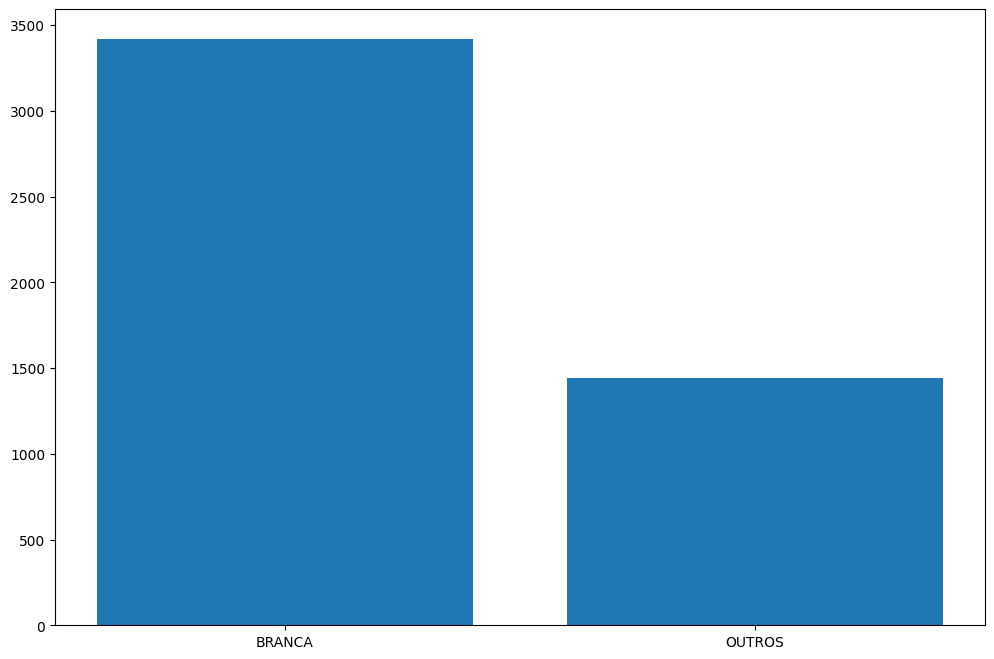

In [8]:
fx, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.bar(cor["cor"], height=cor["count"])
plt.show()

In [9]:
df["ementa"].dropna().count()

4863

## Bag Of Words

In [10]:
# nltk.download('stopwords')

In [11]:
df = df.dropna(subset=["ementa"]).reset_index(drop=True)

In [12]:
tf_idf = TfidfVectorizer(stop_words=(stopwords.words('portuguese')), ngram_range=(1,1) )
X = tf_idf.fit_transform(df["ementa"])
vocab = tf_idf.get_feature_names_out()
vocab

array(['00', '000', '001', ..., 'único', 'útero', 'útil'], dtype=object)

## WORD CLOUD

In [13]:
le = LabelEncoder()

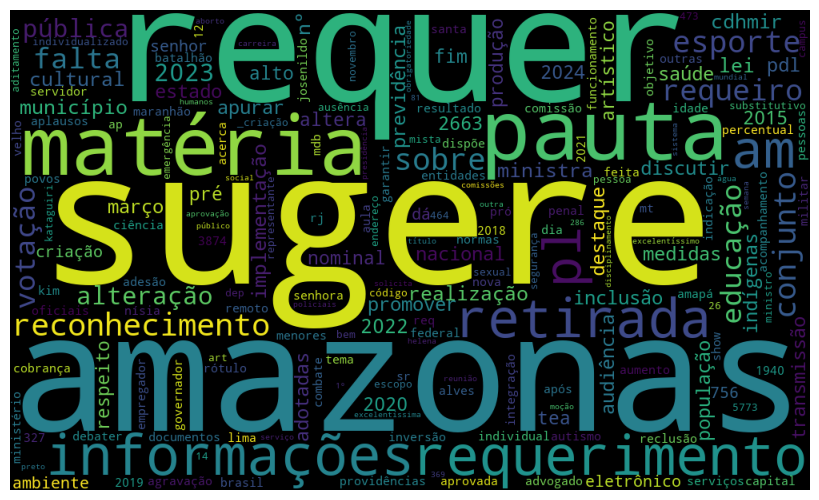

In [14]:
model = RandomForestClassifier(
    n_estimators=1000, random_state=42, n_jobs=-1, max_features=0.1)
y = le.fit_transform(df["cor"])
X_train, X_test, y_train, y_test = train_test_split(X, y)
model.fit(X_train, y_train)
features_importance = model.feature_importances_
features_name = tf_idf.get_feature_names_out()
word_importance = dict(zip(features_name, features_importance))

wordcloud = WordCloud(width = 1000, height = 600, 
                background_color ='black', 
                stopwords = stopwords, 
                min_font_size = 10,
                ).generate_from_frequencies(word_importance)


plt.figure(figsize = (8, 8), facecolor = None) 
plt.imshow(wordcloud) 
plt.axis("off") 
plt.title("")
plt.tight_layout(pad = 0) 
  
plt.show()

In [15]:
df_brancos = df[df["cor"] == "BRANCA"]
df_outros = df[df["cor"] == "OUTROS"]

tf_idf_brancos = TfidfVectorizer(stop_words=(stopwords.words('portuguese')), ngram_range=(1,1) )
tf_idf_outros = TfidfVectorizer(stop_words=(stopwords.words('portuguese')), ngram_range=(1,1) )

y_brancos = le.fit_transform(df_brancos["situacao"])
y_outros = le.fit_transform(df_outros["situacao"])

In [16]:
X_brancos = tf_idf_brancos.fit_transform(df_brancos["ementa"])
vocab_brancos = tf_idf_brancos.get_feature_names_out()


In [17]:
X_outros = tf_idf_outros.fit_transform(df_outros["ementa"])
vocab_outros = tf_idf_outros.get_feature_names_out()



## GRUPO 1: PESSOA DE COR DE PELE BRANCA

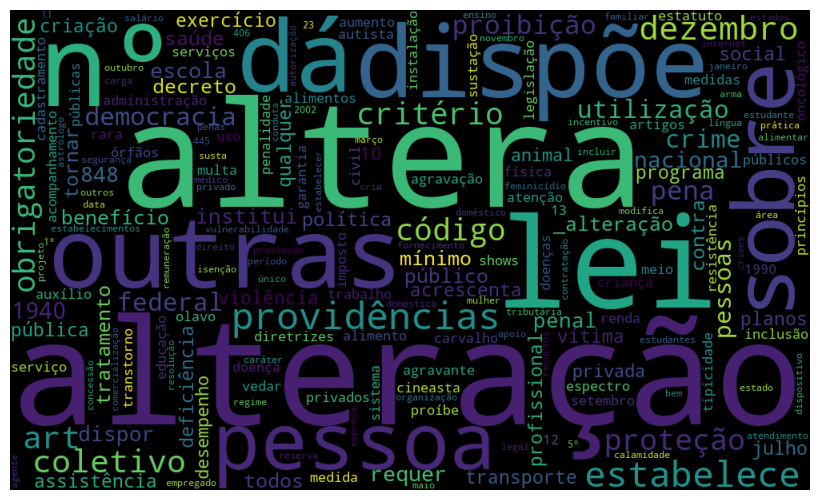

In [18]:
model_brancos = RandomForestClassifier(
    n_estimators=1000, random_state=42, n_jobs=-1, max_features=0.1)

X_train, X_test, y_train, y_test = train_test_split(X_brancos, y_brancos)
model_brancos.fit(X_train, y_train)
features_importance = model_brancos.feature_importances_
features_name = tf_idf_brancos.get_feature_names_out()
word_importance = dict(zip(features_name, features_importance))

wordcloud_brancos = WordCloud(width = 1000, height = 600, 
                background_color ='black', 
                stopwords = stopwords, 
                min_font_size = 10,
                ).generate_from_frequencies(word_importance)


plt.figure(figsize = (8, 8), facecolor = None) 
plt.imshow(wordcloud_brancos) 
plt.axis("off") 
plt.title("")
plt.tight_layout(pad = 0) 
  
plt.show()

## GRUPO 2: PESSOA DE COR DE PELE DIFERENTES 

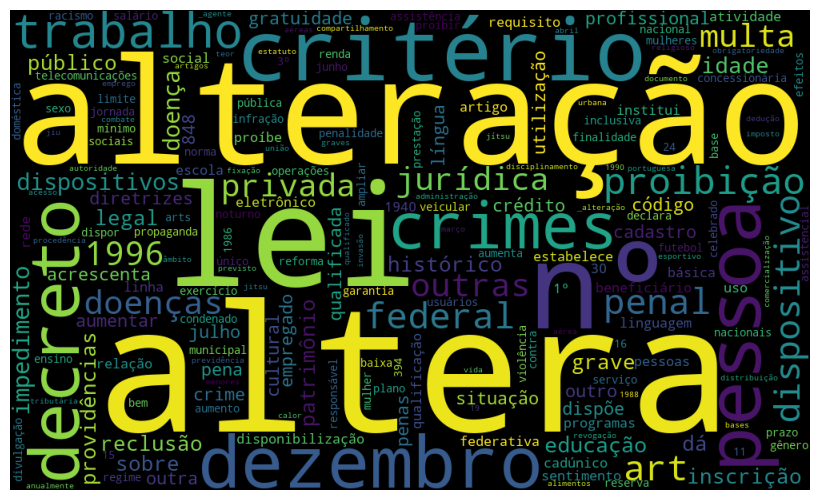

In [19]:
model_outros = RandomForestClassifier(
    n_estimators=1000, random_state=42, n_jobs=-1, max_features=0.1)

X_train, X_test, y_train, y_test = train_test_split(X_outros, y_outros)
model_outros.fit(X_train, y_train)
features_importance = model_outros.feature_importances_
features_name = tf_idf_outros.get_feature_names_out()
word_importance = dict(zip(features_name, features_importance))

wordcloud_outros = WordCloud(width = 1000, height = 600, 
                background_color ='black', 
                stopwords = stopwords, 
                min_font_size = 10,
                ).generate_from_frequencies(word_importance)


plt.figure(figsize = (8, 8), facecolor = None) 
plt.imshow(wordcloud_outros) 
plt.axis("off") 
plt.title("")
plt.tight_layout(pad = 0) 
  
plt.show()

## PCA

In [20]:
le = LabelEncoder()

df["cor"] = le.fit_transform(df["cor"])
y = df["cor"]

In [21]:
df_teste = df

In [22]:
df_teste = df_teste.drop(columns=['nome', 'nome_partido', 'nascimento', 'escolaridade', 'tipo', 'status_partido', 'sigla_partido', 'total_membros_partido', 'local_nascimento', 'sexo', 'ano'])
df_teste['situacao'] = le.fit_transform(df_teste['situacao'])

In [23]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2, svd_solver='full')
# print(X)
X_pca = pca.fit_transform(X.toarray())

In [24]:
X_pca

array([[-0.05392166, -0.06338245],
       [-0.04243428, -0.03542842],
       [-0.06523114, -0.02279986],
       ...,
       [ 0.06165362, -0.02638453],
       [-0.01680869,  0.00931502],
       [ 0.04674537,  0.09738835]])

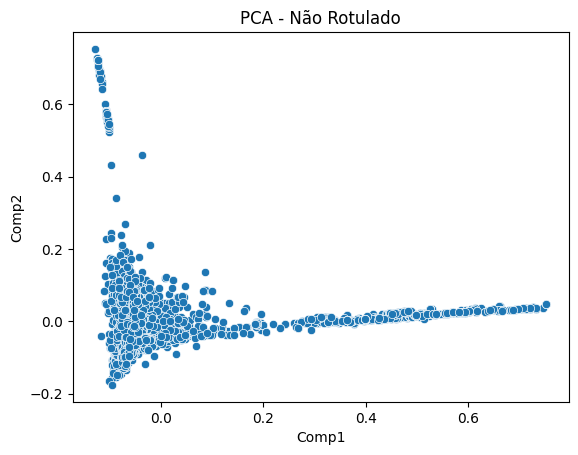

In [25]:

# df_teste = df
# df_teste["ementa"] = X_pca
# df_teste = df_teste.values()
# pca1 = pca.fit_transform(df_teste)
# print(pca1)

df_pca = pd.DataFrame(data=X_pca, columns=['Comp1', 'Comp2'])
df_pca["target"] = df["cor"].reset_index(drop=True)


sns.scatterplot(x='Comp1', y="Comp2", data=df_pca)
plt.title('PCA - Não Rotulado')
plt.show()

In [26]:
df_pca

,Comp1,Comp2,target
0,-0.053922,-0.063382,0
1,-0.042434,-0.035428,1
2,-0.065231,-0.022800,0
3,-0.070476,-0.041945,0
4,-0.034679,-0.059520,0
...,...,...,...
4858,-0.053451,0.032580,1
4859,0.047256,-0.038817,0
4860,0.061654,-0.026385,0
4861,-0.016809,0.009315,0


In [27]:
df_pca.count()

Comp1     4863
Comp2     4863
target    4863
dtype: int64

In [28]:
## TODO pegar os documentos que estão no cluster (0.3 à 0.6, -0.2 à -0.4)

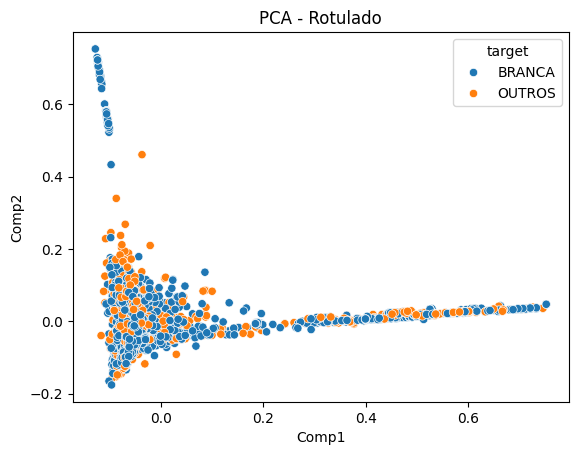

In [29]:
y_map = {0: 'BRANCA', 1: "OUTROS"}

df_pca["target"] = df["cor"].map(y_map)

sns.scatterplot(x='Comp1', y="Comp2", hue="target", data=df_pca)
plt.title('PCA - Rotulado')
plt.show()

In [30]:
cluster1 = df_pca[(df_pca['Comp1'] > -0.1) & (df_pca['Comp1'] < 0.2) & (df_pca['Comp2'] > -0.1) & (df_pca['Comp2'] < 0.2) ]
cluster2 = df_pca[(df_pca['Comp1'] > 0.3) & (df_pca['Comp1'] < 0.6) & (df_pca['Comp2'] > -0.6) & (df_pca['Comp2'] < -0.2) ]

In [31]:
df_pca["target"].value_counts()

target
BRANCA    3421
OUTROS    1442
Name: count, dtype: int64

In [32]:
cluster1["target"].value_counts()

target
BRANCA    2867
OUTROS    1230
Name: count, dtype: int64

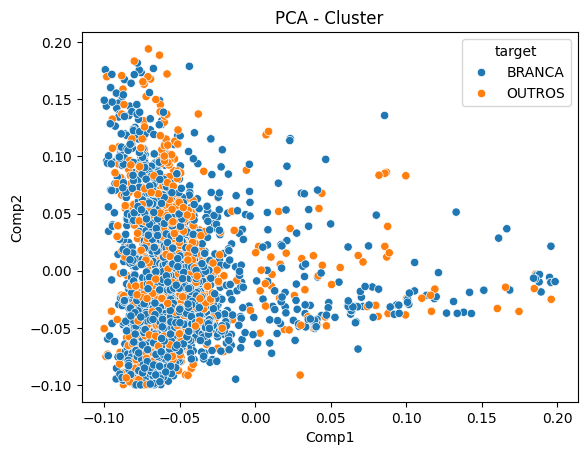

In [33]:
sns.scatterplot(x='Comp1', y="Comp2", hue="target", data=cluster1)
plt.title('PCA - Cluster')
plt.show()

## Treino do Modelo

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
from imblearn.over_sampling import SMOTE

# transform the dataset
oversample = SMOTE()
X_train, y_train = oversample.fit_resample(X_train, y_train)

In [36]:


def evaluation_parametrics(name, y_test, y_pred):
    cm_test = confusion_matrix(y_test, y_pred)
    
    t1 = ConfusionMatrixDisplay(cm_test, display_labels=[
                                "Branca", "Outros"])
    print("Classification Report for Data Test")
    print(classification_report(y_test, y_pred))
    t1.plot()

In [37]:
#K Fold

K = 5
kf = KFold(n_splits=K, shuffle=True, random_state=42) 

# Logistic Regression

In [38]:
model_LR = LogisticRegression(random_state=42, max_iter=1000, solver="liblinear", penalty="l2", C=3, tol=0.001)
cross_val_results = cross_val_score(model_LR, X, y, cv=kf, scoring="f1_macro")
cross_val_results_accuracy = cross_val_score(model_LR, X, y, cv=kf, scoring="accuracy")

print("Resultado da Cross Validation: ", cross_val_results)


print("Media da Accuracy: ", cross_val_results_accuracy.mean())
print("Media da MACRO F1: ", cross_val_results.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results.std())

Resultado da Cross Validation:  [0.55315006 0.61208468 0.59145908 0.58946969 0.54716092]
Media da Accuracy:  0.7283572084131636
Media da MACRO F1:  0.578664888064034
Desvio Padrão da MACRO F1:  0.024660994837142007


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.75      0.80      0.77       670
           1       0.49      0.43      0.46       303

    accuracy                           0.68       973
   macro avg       0.62      0.61      0.62       973
weighted avg       0.67      0.68      0.68       973



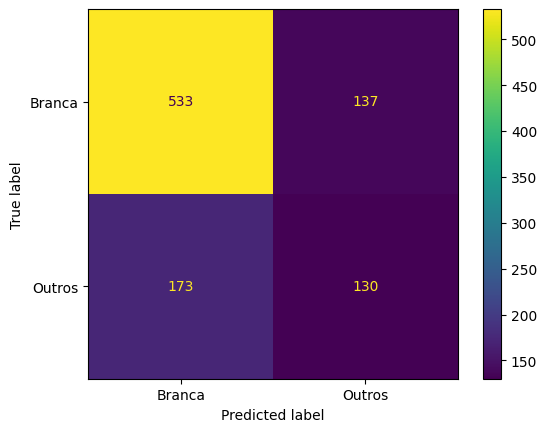

In [39]:
model_LR.fit(X_train, y_train)
y_pred = model_LR.predict(X_test)
evaluation_parametrics("Machine Learning - Logistic", y_test, y_pred)

# SGD Classifier

In [40]:
model_SGD = SGDClassifier(random_state=42, loss="squared_hinge", alpha=0.0001, learning_rate="constant", eta0=0.1, power_t=0.5, penalty="l2", tol=0.001, early_stopping=True, n_jobs=-1, class_weight="balanced")
cross_val_results = cross_val_score(model_SGD, X, y, cv=kf, scoring="f1_macro")
cross_val_results_accuracy = cross_val_score(model_SGD, X, y, cv=kf, scoring="accuracy")

print("Resultado da Cross Validation: ", cross_val_results)

print("Media da Accuracy: ", cross_val_results_accuracy.mean())
print("Media da MACRO F1: ", cross_val_results.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results.std())

Resultado da Cross Validation:  [0.61912824 0.66279231 0.6280793  0.63168143 0.61967601]
Media da Accuracy:  0.6878480284555424
Media da MACRO F1:  0.6322714570366796
Desvio Padrão da MACRO F1:  0.016005214848686364


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.76      0.79      0.77       670
           1       0.49      0.45      0.47       303

    accuracy                           0.68       973
   macro avg       0.63      0.62      0.62       973
weighted avg       0.68      0.68      0.68       973



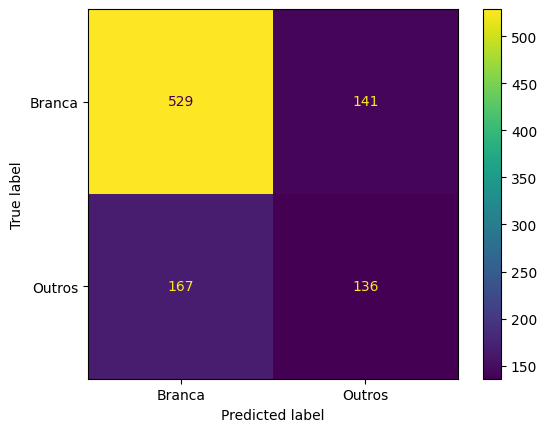

In [41]:
model_SGD.fit(X_train, y_train)
y_pred = model_SGD.predict(X_test)
evaluation_parametrics("Machine Learning - SGD", y_test, y_pred)

# K Neighbors Classifier

In [42]:
model_KNeighbors = KNeighborsClassifier(n_neighbors=5, weights="distance", algorithm="auto", leaf_size=50, p=2 )
cross_val_results = cross_val_score(model_KNeighbors, X, y, cv=kf, scoring="f1_macro", )
cross_val_results_accuracy = cross_val_score(model_KNeighbors, X, y, cv=kf, scoring="accuracy")

print("Resultado da Cross Validation: ", cross_val_results)

print("Media da Accuracy: ", cross_val_results_accuracy.mean())
print("Media da MACRO F1: ", cross_val_results.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results.std())

Resultado da Cross Validation:  [0.56196222 0.60281604 0.60176609 0.60109815 0.59638068]
Media da Accuracy:  0.6975143694568156
Media da MACRO F1:  0.592804637675494
Desvio Padrão da MACRO F1:  0.015577940036663504


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.85      0.28      0.42       670
           1       0.36      0.89      0.51       303

    accuracy                           0.47       973
   macro avg       0.61      0.59      0.46       973
weighted avg       0.70      0.47      0.45       973



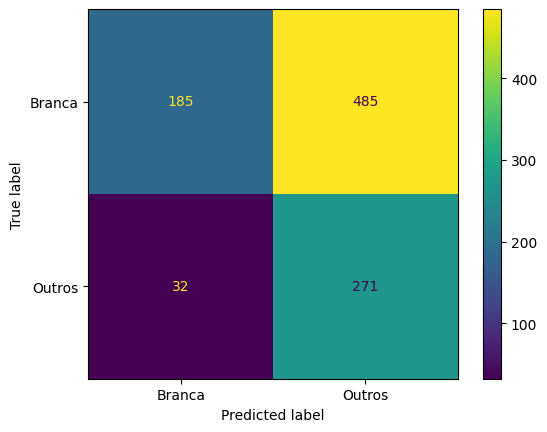

In [43]:
model_KNeighbors.fit(X_train, y_train)
y_pred = model_KNeighbors.predict(X_test)
evaluation_parametrics("Machine Learning - K Neighbors", y_test, y_pred)

# SVM (SUPPORT VECTOR MACHINE)

In [44]:
model_SVM = LinearSVC(random_state=42, loss='squared_hinge', max_iter=1000, penalty="l2", C=3, tol=0.0001, multi_class='ovr', dual=True, class_weight="balanced",  )
cross_val_results = cross_val_score(model_SVM, X, y, cv=kf, scoring="f1_macro")
cross_val_results_accuracy = cross_val_score(model_SVM, X, y, cv=kf, scoring="accuracy")

print("Resultado da Cross Validation: ", cross_val_results)

print("Media da Accuracy: ", cross_val_results_accuracy.mean())
print("Media da MACRO F1: ", cross_val_results.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results.std())

Resultado da Cross Validation:  [0.62430673 0.66186962 0.632546   0.63834125 0.61627637]
Media da Accuracy:  0.6970996747575484
Media da MACRO F1:  0.634667994022274
Desvio Padrão da MACRO F1:  0.015514714668976607


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.76      0.80      0.78       670
           1       0.50      0.44      0.47       303

    accuracy                           0.69       973
   macro avg       0.63      0.62      0.62       973
weighted avg       0.68      0.69      0.68       973



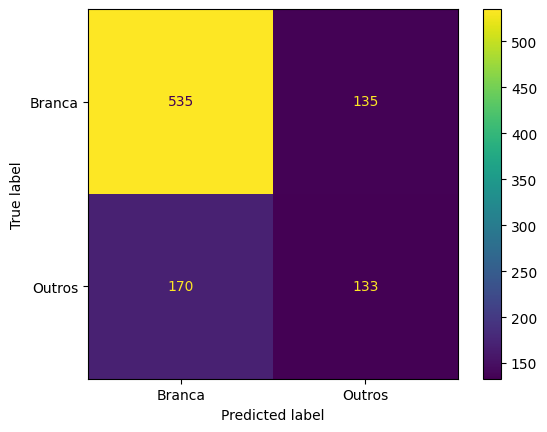

In [45]:
model_SVM.fit(X_train, y_train)
y_pred = model_SVM.predict(X_test)
evaluation_parametrics("Machine Learning - SVM", y_test, y_pred)

# Random Forest

In [46]:
model_Random_Forest = RandomForestClassifier(random_state=42, n_estimators=500, criterion="gini", max_features='sqrt', class_weight='balanced', n_jobs=-1, )
cross_val_results = cross_val_score(model_Random_Forest, X, y, cv=kf, scoring="f1_macro")
cross_val_results_accuracy = cross_val_score(model_Random_Forest, X, y, cv=kf, scoring="accuracy")


print("Resultado da Cross Validation: ", cross_val_results)

print("Media da Accuracy: ", cross_val_results_accuracy.mean())
print("Media da MACRO F1: ", cross_val_results.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results.std())

Resultado da Cross Validation:  [0.55578056 0.55725721 0.60030376 0.57884124 0.5576647 ]
Media da Accuracy:  0.722396051412838
Media da MACRO F1:  0.5699694934676215
Desvio Padrão da MACRO F1:  0.017396619760987744


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.72      0.90      0.80       670
           1       0.52      0.24      0.33       303

    accuracy                           0.69       973
   macro avg       0.62      0.57      0.57       973
weighted avg       0.66      0.69      0.65       973



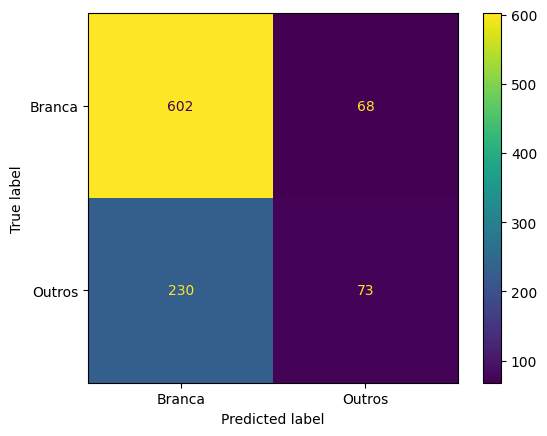

In [47]:
model_Random_Forest.fit(X_train, y_train)
y_pred = model_Random_Forest.predict(X_test)
evaluation_parametrics("Machine Learning - Random Forest", y_test, y_pred)

# Decision Tree

In [48]:
model_Decision_Tree = DecisionTreeClassifier(random_state=42, criterion="entropy", splitter="random", class_weight="balanced", ccp_alpha=0.0001)

cross_val_results = cross_val_score(model_Decision_Tree, X, y, cv=kf, scoring="f1_macro")
cross_val_results_accuracy = cross_val_score(model_Decision_Tree, X, y, cv=kf, scoring="accuracy")

print("Resultado da Cross Validation: ", cross_val_results)

print("Media da Accuracy: ", cross_val_results_accuracy.mean())
print("Media da MACRO F1: ", cross_val_results.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results.std())

Resultado da Cross Validation:  [0.57927509 0.58642393 0.61121955 0.59289948 0.58226026]
Media da Accuracy:  0.6483638486036568
Media da MACRO F1:  0.5904156628547534
Desvio Padrão da MACRO F1:  0.011362465514853804


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.74      0.77      0.75       670
           1       0.44      0.40      0.42       303

    accuracy                           0.65       973
   macro avg       0.59      0.58      0.59       973
weighted avg       0.65      0.65      0.65       973



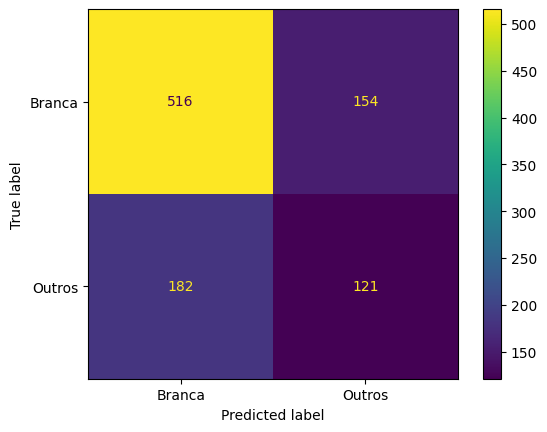

In [49]:
model_Decision_Tree.fit(X_train, y_train)
y_pred = model_Decision_Tree.predict(X_test)
evaluation_parametrics("Machine Learning - Decision Tree", y_test, y_pred)

In [50]:
## Funçao para Avaliação dos Modelos
# Refazer essa parte 
import numpy as np

branca:int = df["cor"].loc[(df["cor"] == 0)].value_counts()
# print(int(branca))
prob_brancos = (int(branca)/len(df["cor"]))

outros:int = df["cor"].loc[(df["cor"] == 1)].value_counts()

prob_outros = (int(outros)/len(df["cor"]))

rng = np.random.default_rng(62)
numbers = rng.random(len(y_test))


balanceamento = [df.loc[df["cor"] == 0].sample(1)  if i < prob_brancos else df.loc[df['cor'] == 1].sample(1) for i in numbers]
df = pd.concat(balanceamento)


from sklearn.metrics import f1_score

f1_score(y_test, df['cor'], average='macro')

0.5002853229856197